<a href="https://colab.research.google.com/github/vishalmahor886/ANN-practical-1/blob/main/ANN_practical_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("savitanair/curn-modelling")

100%|██████████| 262k/262k [00:00<00:00, 65.8MB/s]

Extracting files...


In [2]:
!pip install tensorflow

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
dataset = pd.read_csv(os.path.join(path,'Churn_Modelling.csv'))

In [5]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [6]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
## divide the dataset into independet and dependent features
X=dataset.iloc[:,3:-1]
y=dataset.iloc[:,-1]

In [8]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [9]:
## Feature Engineering
geography=pd.get_dummies(X['Geography'],drop_first=True)
gender=pd.get_dummies(X['Gender'],drop_first=True)

In [10]:
X=X.drop(['Geography', 'Gender'], axis=1)

In [11]:
X=pd.concat([X,geography,gender], axis=1)

In [12]:
## Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [13]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
7389,667,34,5,0.00,2,1,0,163830.64,False,True,False
9275,427,42,1,75681.52,1,1,1,57098.00,True,False,True
2995,535,29,2,112367.34,1,1,0,185630.76,False,False,False
5316,654,40,5,105683.63,1,1,0,173617.09,False,True,True
356,850,57,8,126776.30,2,1,1,132298.49,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9225,594,32,4,120074.97,2,1,1,162961.79,True,False,False
4859,794,22,4,114440.24,1,1,1,107753.07,False,True,False
3264,738,35,5,161274.05,2,1,0,181429.87,False,False,True
9845,590,38,9,0.00,2,1,1,148750.16,False,True,False


In [14]:
# feature scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [15]:
X_train.shape

(8000, 11)

In [16]:
## ANN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, ReLU, PReLU
from tensorflow.keras.layers import Dropout

In [17]:
#Initialize the ANN
classifier=Sequential()

In [18]:
## Adding input layer
classifier.add(Dense(units=11, activation='relu'))

In [19]:
## adding first hidden layer
classifier.add(Dense(units=7, activation='relu'), Dropout(0.2))

In [20]:
##adding the second hidden layer
classifier.add(Dense(units=6, activation='relu'))

In [21]:
#adding the output layer
classifier.add(Dense(units=1, activation='sigmoid'))

In [22]:
import tensorflow
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [23]:
classifier.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [24]:
## Early stopping
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)


In [25]:
model_history=classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=1000, callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8069 - loss: 0.4334 - val_accuracy: 0.8304 - val_loss: 0.3922
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8474 - loss: 0.3623 - val_accuracy: 0.8440 - val_loss: 0.3711
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8545 - loss: 0.3553 - val_accuracy: 0.8508 - val_loss: 0.3602
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8563 - loss: 0.3480 - val_accuracy: 0.8485 - val_loss: 0.3655
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8571 - loss: 0.3447 - val_accuracy: 0.8402 - val_loss: 0.3693
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8589 - loss: 0.3435 - val_accuracy: 0.8470 - val_loss: 0.3623
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8628 - loss: 0.3425 - val_accuracy: 0.8417 - val_loss: 0.3614
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8582 - loss: 0.3416 - 

In [26]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

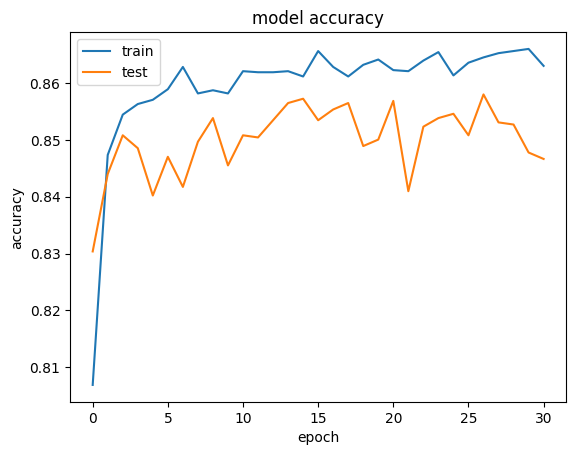

In [27]:
## summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

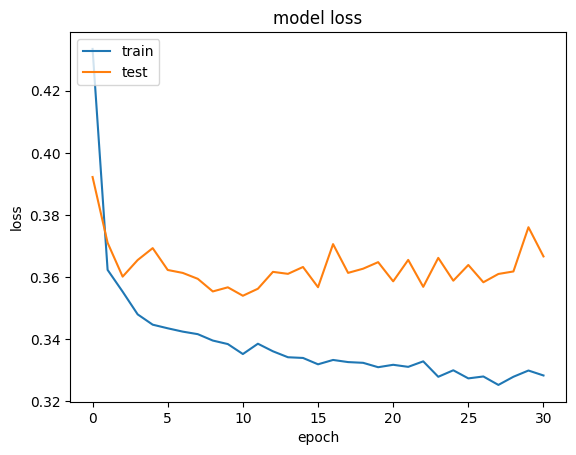

In [28]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

In [29]:
##part 3 - making the prediction and evaluating the model

# predicting the test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [30]:
## make confusion matrixs
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

In [31]:
cm

array([[1531,   64],
       [ 216,  189]])

In [32]:
## calculate the accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)

In [33]:
score

0.86

In [34]:
## get the weights
classifier.get_weights()

[array([[-0.89792615, -0.18843848,  1.4071945 , -0.4681236 , -0.03223781,
          0.40417   , -0.59542775, -0.11037882,  0.07806711, -0.43943927,
          0.0864415 ],
        [ 0.00373554,  2.7827961 , -1.9613293 ,  1.1325345 , -0.09963512,
          0.02921562, -2.7595086 ,  1.9942372 , -1.3746898 ,  0.19909571,
         -1.7828219 ],
        [ 0.60295016,  0.55063146, -0.30425847,  0.10359298,  0.03822825,
          0.5840819 , -0.10224847,  0.08299179,  1.5929743 , -0.31923163,
          0.7562947 ],
        [-0.66958016,  0.7442871 , -0.59736806, -2.1621706 ,  0.06326623,
         -2.6877236 , -0.6402686 , -0.35882354, -0.13775153, -0.89500356,
         -0.7683312 ],
        [ 1.0104215 ,  0.43463296, -1.0435454 , -2.757948  ,  3.1432452 ,
          1.5895486 ,  0.58607566, -0.85832155, -0.2955382 ,  1.847644  ,
         -0.07712514],
        [-0.9081692 , -0.3257145 ,  2.2195747 , -0.19992182,  0.04604444,
         -0.08753067, -0.95783   , -0.02767725,  1.009544  ,  0.6232695